In [41]:
### Setup to equivalently run in colab or run locally ###
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB: # setup for colab

    # Initialize widget
    from google.colab import output
    output.enable_custom_widget_manager()

    # Colab-specific widget support
    !pip install -U ipympl --quiet

    # Clone repo and cd into it to behave like running locally
    %cd /content
    if not os.path.exists("arc_zte"):
      print("Cloning repo")
      !git clone https://github.com/mikgroup/arc_zte.git
    %cd /content/arc_zte
    # Pull in case repo was already cloned
    !git pull

    # Download data from OSF
    !pip install osfclient --quiet
    if not os.path.exists('data_for_arczte_paper/ge_phantom'):
      print("Downloading data from OSF. This will take ~5min..")
      PROJECT_ID = 'c3sp5'
      !osf -p {PROJECT_ID} clone ./
      !mv /content/arc_zte/osfstorage/* ./
      !rm -rf /content/arc_zte/osfstorage
    
    # Set path to data
    local_data_path = './data_for_arczte_paper/acr_phantom/'

    # Setup env
    !pip install -r requirements.txt --quiet
      
    # Setup matplotlib mode
    try:
      %matplotlib widget
    except:
      %matplotlib inline
      print('Running inline mode')
        
    # Set to CPU
    device_num = -1

elif not IN_COLAB: # setup for running locally
    
    from zte_recon.util.os_util import set_gpu, set_num_cpus
    
    # Set local data path (download from DOI linked on README)
    local_data_path = './data_for_arczte_paper/acr_phantom/'
    if not os.path.exists(local_data_path):
        raise NotADirectoryError('Data directory not found!')
   
    # Local Jupyter 
    %matplotlib notebook

    # Set GPU device for recon or -1 for CPU.
    device_num = 0
    set_gpu(device_num)
    set_num_cpus(36)

In [55]:
### Setup BART ###

if IN_COLAB:
    # Clone and compile BART
    !git clone git@github.com:s-ramachandran/bart.git 
    %cd bart
    !make &> /dev/null
    %cd ../

    # Setup paths
    os.environ['BART_TOOLBOX_PATH']=os.getcwd()+"/bart/"

else: # if running locally
    
    # set to your BART compilation
    os.environ['BART_TOOLBOX_PATH']="./bart/"

os.environ['PATH'] = os.environ['BART_TOOLBOX_PATH'] + ":" + os.environ['PATH']
sys.path.append(os.environ['BART_TOOLBOX_PATH'] + "/python/")

# Import BART
import bart

In [56]:
import numpy as np
import sigpy as sp
import matplotlib.pyplot as plt
import sigpy.plot as pl
import glob
from tqdm import tqdm

from zte_recon.data_zte import Data_Arc_ZTE, Data_CalcPhyllo_ZTE, Data_EndpointsFile_ZTE
from zte_recon.recon_gridding import recon_adjoint_postcomp_coilbycoil
from zte_recon.arc_zte_traj import read_params_from_kacq
from zte_recon.util.os_util import set_gpu
from zte_recon.util.sens import est_maps_3d
from zte_recon.util.bart_dims import ksp_to_bart, coord_to_bart

In [78]:
## Params for user to set

# Set DEMO_MODE to False if not running as a demo
# or True if just want to test if cells will run without failing
DEMO_MODE = True

if DEMO_MODE:
    img_shape = [64,64,64]
    nPtsPerSpoke = 64 # fewer pts per spoke
else:
    img_shape = [128, 128, 128]
    nPtsPerSpoke = 128

In [68]:
# Reconstruction parameters
FOV_scale = 1.25
FOV_scale_dir = [1,1,1]
rBW = 31.25e3

# To account for coil ringing, drop extra points at spoke start
ndrop_ROpts = 1 

# For optimization
lamda_wav = 0.001
poly_deg = 4 # degree for polynomial preconditioner

# Load phantom data

In [79]:
# Golden angle rotations of Arc-ZTE segments
seg_rot_file = './rot_txt_files/seg_golden3d_rotMats.txt'

################

### Arc ZTE scheme - 13 deg
h5_save_dir = local_data_path + 'arczte13/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte*')[-1]
acq_params = read_params_from_kacq(kacq_file)

Data_arc13 = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Data_arc13.gradient_corr(-0.25)


##############

### Arc ZTE scheme - 53 deg
h5_save_dir = local_data_path + 'arczte53/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte*')[-1]
acq_params = read_params_from_kacq(kacq_file)

Data_arc53 = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Data_arc53.gradient_corr(-0.25)

##############

### Arc ZTE scheme - 84 deg
h5_save_dir = local_data_path + 'arczte83/'
kacq_file = glob.glob(h5_save_dir + 'kacq_arc_zte*')[-1]
acq_params = read_params_from_kacq(kacq_file)

Data_arc83 = Data_Arc_ZTE(kacq_file, seg_rot_file, acq_params, h5_save_dir,
                                    FOV_scale=FOV_scale, FOV_scale_dir=FOV_scale_dir, 
                                    ndrop_ROpts=ndrop_ROpts, nPtsPerSpoke=nPtsPerSpoke)
Data_arc83.gradient_corr(-0.25)


###############

### Phyllotaxis
h5_save_dir = local_data_path + 'phyllozte/'

smoothness = 10
gm_flag = False
segsPerInterleaf = 1

Data_phyllozte = Data_CalcPhyllo_ZTE(smoothness, gm_flag, segsPerInterleaf, 
                                     h5_save_dir, nPtsPerSpoke, rBW, 
                                     FOV_scale, FOV_scale_dir, ndrop_ROpts)
Data_phyllozte.gradient_corr(-0.25)

###############

### AZTEK
h5_save_dir = local_data_path + 'aztek/'
endpoints_txt_path = glob.glob(h5_save_dir + 'kacq_aztek*')[-1]

Data_aztek = Data_EndpointsFile_ZTE(endpoints_txt_path, 
                 h5_save_dir, nPtsPerSpoke, rBW,
                 FOV_scale, FOV_scale_dir, ndrop_ROpts)
Data_aztek.gradient_corr(-0.25)

#############

# Standard
h5_save_dir = local_data_path + 'stdzte/'
endpoints_txt_path = glob.glob(h5_save_dir + 'kacq_stdzte*')[-1]

Data_standard = Data_EndpointsFile_ZTE(endpoints_txt_path, 
                 h5_save_dir, nPtsPerSpoke, rBW,
                 FOV_scale, FOV_scale_dir, ndrop_ROpts)
Data_standard.gradient_corr(-0.25)

# Concatenate into a list
list_dataObjs = [Data_aztek, Data_phyllozte, Data_arc13, Data_arc53, Data_arc83]
list_data_names = ['aztek', 'phyllozte', 'arczte', 'arczte', 'arczte']

Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/arczte13/
Applied gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/arczte53/
Applied gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/arczte83/
Applied gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/phyllozte/
Applying gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/aztek/
Applying gradient delay correction of -0.25
Loading ksp from h5 dir: ./data_for_arczte_paper/acr_phantom/stdzte/
Applying gradient delay correction of -0.25


# Estimate coil sensitivites

In [87]:
# Run function that grids WASPI data into lowres cartesian then runs ESPIRiT
crop_thres = 0.001
grid_size = 10
ker_size = 4

# Take standard arrangement of WASPI spokes
ksp_waspi = ksp_to_bart(Data_standard.ksp_waspi)
coord_waspi = coord_to_bart(Data_standard.coord_waspi)

# Run ESPIRiT
maps = est_maps_3d(ksp_waspi, coord_waspi,
                  img_shape=img_shape,
                  crop_thres=crop_thres, 
                   soft_sens=False,
                   ker_size=ker_size,
                  grid_size=grid_size)

In [58]:
pl.ImagePlot(maps)

<IPython.core.display.Javascript object>

# Reconstruct across different temporal intervals

In [88]:
def reconstruct_spokes_subset(DataObj, nSpokes, sensmaps, img_shape, 
                              scale_factor=1e4, lamda_l1_wav=0.1, 
                              num_iters=20, degree=8):
    
    ksp_full = ksp_to_bart(DataObj.ksp_hires[:, 0:nSpokes, :] / scale_factor)
    coord_full = coord_to_bart(DataObj.coord_sampl_hires[0:nSpokes, :])

    bart_cmd = f"pics -d 5 -i {num_iters} -R W:7:0:{lamda_l1_wav} --polyprecond --degree {degree} -t"
    im_l1_recon = bart.bart(1, bart_cmd, coord_full, ksp_full, sensmaps)
        
    return im_l1_recon

In [ ]:
# Run the recon - note that this cell takes around 3min in DEMO_MODE
if DEMO_MODE:
    nSpokes_list = [200]
    num_iters = 20
else:
    nSpokes_list = [400, 512, 800, 1024, 1200]
    num_iters = 60
    
# Initialize storage
im_recon_all = np.zeros((len(nSpokes_list), len(list_dataObjs), 
                        *img_shape), dtype=np.complex128)
    
for j, dataObj in enumerate(list_dataObjs):
    
    scheme_name = list_data_names[j]
    print(f"Reconstructing data for {scheme_name}")
    
    # Correction of flipped axes prescription in scanner
    if scheme_name == 'phyllozte':
        maps_transpose = np.flip(maps, axis=-3)
    elif scheme_name == 'arczte':
        maps_transpose = np.flip(maps.transpose(1,0,2,3), axis=-3)
    elif scheme_name == 'aztek':
        maps_transpose = np.copy(maps)
    
    for i, nSpokes in enumerate(tqdm(nSpokes_list)):
        
        im_recon = reconstruct_spokes_subset(dataObj, 
                                             nSpokes, 
                                             maps_transpose, 
                                             img_shape, 
                                             lamda_l1_wav=lamda_wav, 
                                             num_iter=num_iters, 
                                             degree=poly_deg)
        
        im_recon_all[i, j] = im_recon 

# Plot

Plotting results for {nSpokes_list[idx_to_plot]} spokes


<IPython.core.display.Javascript object>


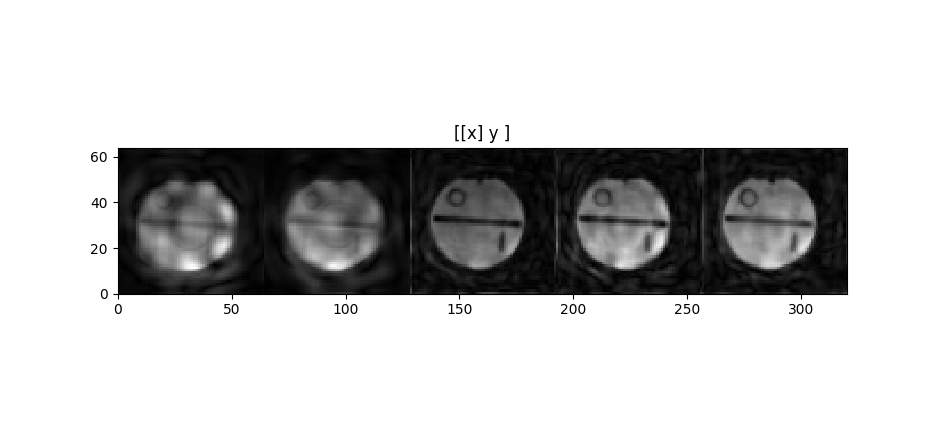

In [128]:
idx_to_plot = 0

print('Plotting results for {nSpokes_list[idx_to_plot]} spokes')

pl.ImagePlot(np.concatenate((
                      np.flip(im_recon_all[idx_to_plot, 0].transpose(1,0,2), axis=(-2, -3)), 
                      np.flip(im_recon_all[idx_to_plot, 1].transpose(1,0,2), axis=(-2)), 
                      np.flip(im_recon_all[idx_to_plot, 2], axis=(-3)), 
                      np.flip(im_recon_all[idx_to_plot, 3], axis=(-3)), 
                      np.flip(im_recon_all[idx_to_plot, 4], axis=(-3))), axis=-3)[:, :, img_shape[2]//2])